# **Machine Learning and Forecasting: Seminar 5**

In [73]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, roc_curve, auc, roc_auc_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pymannkendall as mk
from scipy import stats
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

# Part A: Questions with hints
- Interpret the result of each question where possible.

##A.1. Difficulty Level: Simple to Intermediate

Q1: Read the dataset *air-passenger-time-series.csv* into Python. The detailed description of this dataset can be found on https://www.kaggle.com/datasets/ashfakyeafi/air-passenger-data-for-time-series-analysis. Provide Python code to perform the hold-out method: define a subset as the training dataset and the rest as the test dataset. <font face="Calibri" size=1.5 color='#3543cd'> Note: You can define the data before a given date as the training dataset and the rest as the test dataset.<font>

In [33]:
airpassengertimeseries = pd.read_csv("Datasets/air-passenger-time-series.csv", parse_dates=['Month'], index_col='Month')

/tmp/ipykernel_442/512755208.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  airpassengertimeseries = pd.read_csv("Datasets/air-passenger-time-series.csv", parse_dates=['Month'], index_col='Month')


In [34]:
airpassengertimeseries.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Passengers  144 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


In [41]:
train = airpassengertimeseries[:132]
test = airpassengertimeseries[132:]

In [43]:
test

,Passengers
Month,
1960-01-01,417.0
1960-02-01,391.0
1960-03-01,419.0
1960-04-01,461.0
1960-05-01,472.0
1960-06-01,535.0
1960-07-01,622.0
1960-08-01,606.0
1960-09-01,508.0


Q2: Create a time series plot, which is a line graph that visualises numerical data collected sequentially over time, with time on the horizontal (X-axis) and the measured variable on the vertical (Y-axis) to reveal trends.

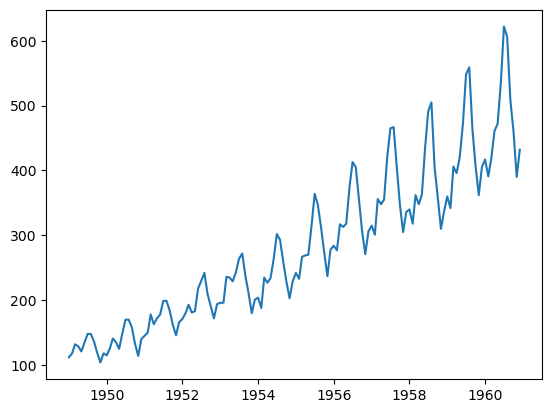

In [37]:
plt.plot(airpassengertimeseries)

Q3: Provide Python code to conduct a Mann-Kendall trend test on *Passengers* and suggest whether there is a trend or not. What is the business implication of your suggestion? <font face="Calibri" size=1.5 color='#3543cd'> Note: You can import a library `import pymannkendall as mk` (install it using `!pip install pymannkendall
` before the application if needed. Then call `mk` by using `mk(data)`, assuming the name of your time series is) .<font>

In [38]:
result = mk.original_test(airpassengertimeseries)
print(result.trend, result.p)

increasing 0.0


Q4: Provide Python code to conduct a Kruskal-Wallis Test on *Passengers* and suggest whether seasonality is present. What is the business implication of your suggestion?  <font face="Calibri" size=1.5 color='#3543cd'> Note: You can import a library `from scipy import stats`. See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html for the use of the function of kruskal.<font>

In [44]:
# Ensure the index is datetime
airpassengertimeseries.index = pd.to_datetime(airpassengertimeseries.index)

# Extract month number from the index
airpassengertimeseries["month_num"] = airpassengertimeseries.index.month

# Group Passengers by calendar month
groups = [
    airpassengertimeseries.loc[airpassengertimeseries["month_num"] == m, "Passengers"]
    for m in range(1, 13)
]

# Kruskal–Wallis test
statistic, p_value = stats.kruskal(*groups)

print(f"Kruskal–Wallis H statistic: {statistic:.3f}")
print(f"p-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H₀: evidence of seasonality is present.")
else:
    print("Fail to reject H₀: no strong evidence of seasonality.")

Kruskal–Wallis H statistic: 11.148
p-value: 0.43092
Fail to reject H₀: no strong evidence of seasonality.


Q5: Fit the time series dataset with an exponential smoothing model with the smoothing level to be 0.6 and an exponential smoothing model with the smoothing level optimised by the library `SimpleExpSmoothing`. Comparing the performance, i.e., MAE (Mean Absolut Error) of the two models, which model would you like to select? Why?<font face="Calibri" size=1.5 color='#3543cd'> Note: You can import a library `from statsmodels.tsa.api import SimpleExpSmoothing`, and see  https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.SimpleExpSmoothing.html and https://www.geeksforgeeks.org/artificial-intelligence/exponential-smoothing-for-time-series-forecasting/ for relevant information.<font>

In [50]:
fit1 = SimpleExpSmoothing(train, initialization_method="heuristic").fit(smoothing_level=0.6)
fit2 = SimpleExpSmoothing(train, initialization_method="estimated").fit()

#to forecast the time series with models fit1 and fit2, respectively
numStep = 12											                                                                      #the number (i.e.,12) of steps forward to be forecasted.
fit1_forecasting = fit1.forecast(numStep).rename(r"$\alpha=0.6$") 				                              #to make a numStep-setp forward forecast based on model fit1
fit2_forecasting = fit2.forecast(numStep).rename(r"$\alpha=%s$" % fit2.model.params["smoothing_level"])	#to make a numStep-setp forward forecast based on model fit2

print(f'Mean Absolute Error of model 1= {mean_absolute_error(fit1_forecasting,test)}')				#find out the MSE of model fit1 on the test dataset
print(f'Mean Absolute Error of model 2= {mean_absolute_error(fit2_forecasting,test)}')				#find out the MSE of model fit2 on the test dataset

Mean Absolute Error of model 1= 78.99129876657321
Mean Absolute Error of model 2= 76.00000042716663


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Q6: Fit the time series dataset with Holt's model with the smoothing level to be 0.6 and trend smoothing factor to be 0.3; and an exponential smoothing model with the smoothing level optimised by the library `Holt`. Comparing the performance, i.e., MAE (Mean Absolut Error) of the two models, which model would you like to select? Why? <font face="Calibri" size=1.5 color='#3543cd'> Note: You can import a library `from statsmodels.tsa.api import Holt`, and see https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.Holt.html and https://www.geeksforgeeks.org/artificial-intelligence/exponential-smoothing-for-time-series-forecasting/ for relevant information.<font>

In [57]:
fit3 = Holt(train, initialization_method="heuristic").fit(smoothing_level=0.6, smoothing_trend = 0.3)
fit4 = Holt(train, initialization_method="estimated").fit()

#to forecast the time series with models fit1 and fit2, respectively
numStep = 12											                                                                      #the number (i.e.,12) of steps forward to be forecasted.
fit3_forecasting = fit3.forecast(numStep).rename(r"$\alpha=0.6$") 				                              #to make a numStep-setp forward forecast based on model fit1
fit4_forecasting = fit4.forecast(numStep).rename(r"$\alpha=%s$" % fit4.model.params["smoothing_level"])	#to make a numStep-setp forward forecast based on model fit2

print(f'Mean Absolute Error of model 3= {mean_absolute_error(fit3_forecasting,test)}')				#find out the MSE of model fit1 on the test dataset
print(f'Mean Absolute Error of model 4= {mean_absolute_error(fit4_forecasting,test)}')	

Mean Absolute Error of model 3= 203.22357232208887
Mean Absolute Error of model 4= 66.30771921110772


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Q7: Fit the time series dataset with Holt-Winter's model with the smoothing level to be 0.6, trend smoothing factor to be 0.3, and smoothing constant for seasonality estimate to be 0.4; and an exponential smoothing model with the smoothing level optimised by the library `ExponentialSmoothing`. Comparing the performance, i.e., MAE (Mean Absolut Error) of the two models, which model would you like to select? Why? <font face="Calibri" size=1.5 color='#3543cd'> Note: You can import a library `from statsmodels.tsa.api import SimpleExpSmoothing`, and see https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html and https://www.geeksforgeeks.org/artificial-intelligence/exponential-smoothing-for-time-series-forecasting/ for relevant information.<font>

In [63]:
fit5 = ExponentialSmoothing(train, initialization_method="heuristic",trend='add',seasonal='add',seasonal_periods=12,).fit(smoothing_level=0.6, smoothing_trend = 0.3, smoothing_seasonal = 0.4)
fit6 = ExponentialSmoothing(train, initialization_method="estimated",trend='add',seasonal='add',seasonal_periods=12,).fit()

#to forecast the time series with models fit1 and fit2, respectively
numStep = 12											                                                                      #the number (i.e.,12) of steps forward to be forecasted.
fit5_forecasting = fit5.forecast(numStep).rename(r"$\alpha=0.6$") 				                              #to make a numStep-setp forward forecast based on model fit1
fit6_forecasting = fit6.forecast(numStep).rename(r"$\alpha=%s$" % fit6.model.params["smoothing_level"])	#to make a numStep-setp forward forecast based on model fit2

print(f'Mean Absolute Error of model 5= {mean_absolute_error(fit5_forecasting,test)}')				#find out the MSE of model fit1 on the test dataset
print(f'Mean Absolute Error of model 6= {mean_absolute_error(fit6_forecasting,test)}')	

Mean Absolute Error of model 5= 50.146288592121856
Mean Absolute Error of model 6= 13.38212820153909


/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/conda/lib/python3.12/site-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Q8: Comparing the performance---MAE (mean absolute error), for instance---of the three modelling methods, Q5, Q6, and Q7, which method would you like to use? Why?

# Part B: Case study

This case study aims to forecast employment with the dataset *Wisconsin-employment-time-series.csv*, downloaded from https://github.com/PacktPublishing/Practical-Time-Series-Analysis/blob/master/Data%20Files/wisconsin-employment-time-series.csv.
Based on this dataset, answer each of the questions in Part A.

#Part C: Challenging questions

Q9: Provide Python code to sraphically show how you decompose the time series dataset `elecequip.csv` into trend, seasonal pattern, and residual component term, respectively. See https://rdrr.io/cran/fpp/man/elecequip.html for the description of the dataset elecequip.csv.  <font face="Calibri" size=1.5 color='#3543cd'> See https://www.statology.org/how-to-perform-seasonal-decomposition-of-time-series-in-python/ for more reference. <font>

In [68]:
elecequip = pd.read_csv("Datasets/elecequip.csv", parse_dates=['Month'], index_col='Month')

# Perform seasonal decomposition
result = seasonal_decompose(elecequip, model='additive')

# Extract components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

/tmp/ipykernel_442/3002712197.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  elecequip = pd.read_csv("Datasets/elecequip.csv", parse_dates=['Month'], index_col='Month')


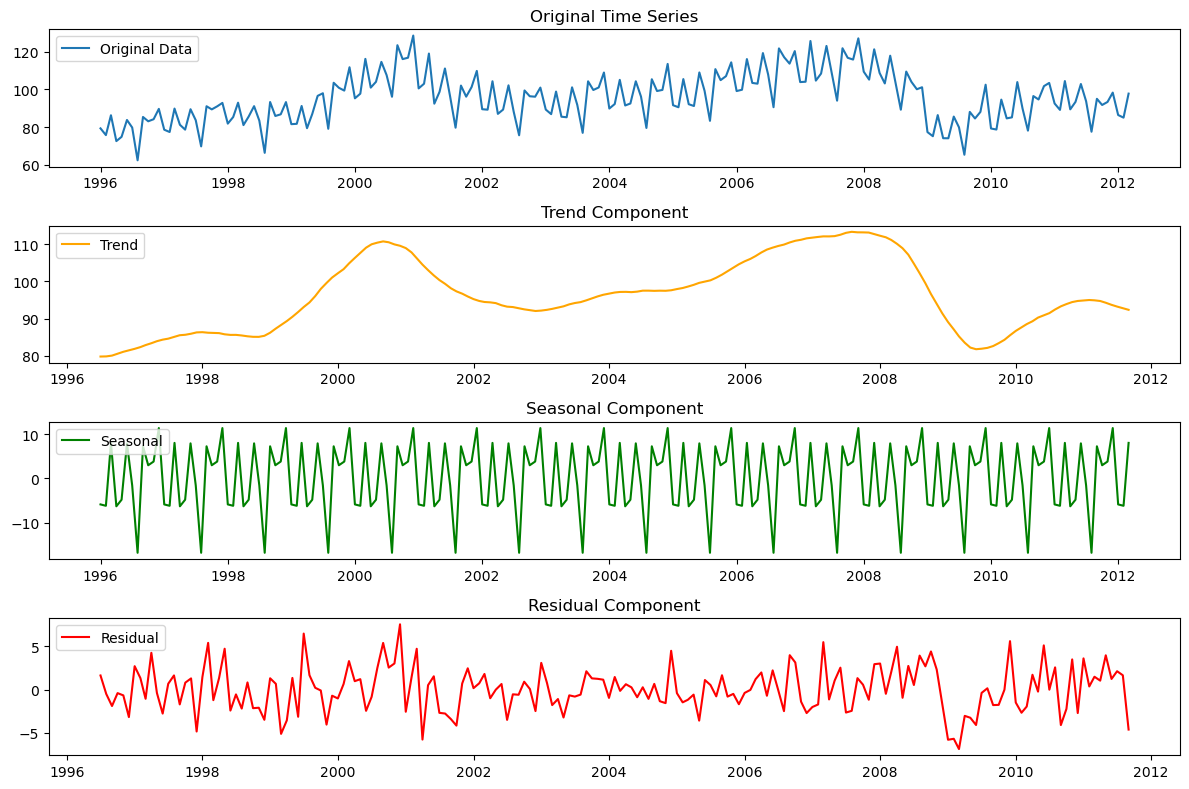

In [70]:
# Plotting the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(elecequip, label='Original Data')
plt.legend(loc='upper left')
plt.title('Original Time Series')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

Q10. Draw a seasonal plot for the dataset `air-passenger-time-series.csv`, which is the one used in Q1, and a season plot for the dataset `elecequip.csv` in Q9.  <font face="Calibri" size=1.5 color='#3543cd'> See https://codesignal.com/learn/courses/mastering-time-series-data-visualization/lessons/visualizing-seasonality-with-seaborn-line-plots for reference. <font>

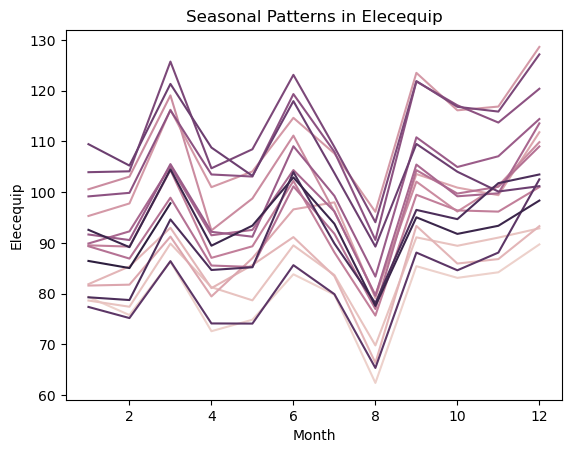

In [78]:
# Create month and year columns for plotting
elecequip["month"] = elecequip.index.month
elecequip["year"] = elecequip.index.year

# Line plot showing seasonal patterns across years
sns.lineplot(
    data=elecequip,
    x="month",
    y="Elecequip",
    hue="year",
    legend=False   # optional: avoids clutter
)

# Titles and labels
plt.title("Seasonal Patterns in Elecequip")
plt.xlabel("Month")
plt.ylabel("Elecequip")

plt.show()

In [ ]:
# Create month and year columns for plotting
airpassengertimeseries["month"] = airpassengertimeseries.index.month
airpassengertimeseries["year"] = airpassengertimeseries.index.year

# Line plot showing seasonal patterns across years
sns.lineplot(
    data=airpassengertimeseries,
    x="month",
    y="Passengers",
    hue="year",
    legend=False   # optional: avoids clutter
)

# Titles and labels
plt.title("Seasonal Patterns in Monthly Passenger Numbers")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")

plt.show()

Q11: In Seminar 2, we practised the forward feature selection method and the backward feature selection method for linear regression modelling (OLS), respectively, for which we introduced two functions. An alternative method is to use function `SequentialFeatureSelector` from library `from sklearn.feature_selection import SequentialFeatureSelector`. The function `SequentialFeatureSelector` can be used as a tool for feature selection for many modelling methods, including multiple linear regression, logistic regression, etc. In this practice, apply the forward feature selection method on `telecom_churn.csv`, which is downloaded from https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset. <font face="Calibri" size=3.5 color='#3543cd'> The webpage https://www.geeksforgeeks.org/machine-learning/sequential-feature-selection/ provides an example that only two features are selected in a logistic regression model. You may write Python code or manually try different numbers of features for logistic regression models and then select a model with the largest AUC (or accuracy, or precision). <font>


## Summary
- Understand the methods of statistical test for detecting trend and of statistical test for detecting seasonaility, respectively;
- Understand the time series forecasting methods, including the simple exponential smoothing method, the Holt's method, the Hold-Winter's method, and the Prophet method.


## Suggested reading for the Next Lecture
- To review the following chapters in the book ***Auffarth, B. (2021). Machine learning for time-series with python. UK: Packt Publishing.***:
   1. Chapter 5.


